# **Лабораторна робота №5**

### **Тема.** Алгоритми пошуку
### **Мета:** засвоїти варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності.
**Виконав:** Заїченко А.С.

**Завдання: реалізувати контрольні приклади, які розглядаються в цій роботі, та виконати завдання до самостійної роботи.**

In [18]:
# Якщо елемент не буде знайдено, виводиться -1
def linear_search(a_list, x):
    i, length = 0, len(a_list)
    
    while i < length and x != a_list[i]:
        i += 1
        
    return i if i < length else -1
a = [32, 1, 3, 4, 2, 1]
search_item = 7
print(linear_search(a, search_item))

-1


Алгоритм лінійного пошуку послідовно переглядає всі елементи масиву, поки не знайде потрібний елемент або не дійде до кінця масиву.
* У найгіршому випадку необхідно переглянути всі n елементів масиву. Тому часова складність алгоритму лінійного пошуку: O(n)
* Просторова складність алгоритму: O(1) оскільки використовується лише кілька додаткових змінних незалежно від розміру масиву.

**оцінити асимптотичну складність алгоритму бінарного пошуку в О-нотації.**

Алгоритм бінарного пошуку працює лише з відсортованими масивами. На кожному кроці він порівнює шуканий елемент із середнім елементом масиву та відкидає половину елементів. Тобто після кожної ітерації розмір області пошуку зменшується у 2 рази. Кількість таких поділів дорівнює логарифму від кількості елементів масиву. Тому часова складність алгоритму бінарного пошуку: **O(logn)**
* для рекурсивної реалізації: O(logn) через стек рекурсивних викликів;
* для ітеративної реалізації:O(1)

**написати функцію, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функції linear_searh();**

In [19]:
import time
import pandas as pd
def linear_search(arr, x):
    for i in range(len(arr)):
        if arr[i] == x:
            return i
    return -1
def linear_dataframe(sizes):
    results = []
    for n in sizes:
        arr = list(range(n))
        target = n - 1
        start = time.time()
        linear_search(arr, target)
        end = time.time()
        results.append((n, end - start))
    return pd.DataFrame(results, columns=["n", "time"])

**написати функцію, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функції bin_searh();**

In [20]:
def bin_search(arr, x, left, right):
    if left > right:
        return -1
    middle = (left + right) // 2
    if arr[middle] == x:
        return middle
    elif arr[middle] < x:
        return bin_search(arr, x, middle + 1, right)
    else:
        return bin_search(arr, x, left, middle - 1)
def binary_dataframe(sizes):
    results = []
    for n in sizes:
        arr = list(range(n))
        target = n - 1
        start = time.time()
        bin_search(arr, target, 0, n - 1)
        end = time.time()
        results.append((n, end - start))
    return pd.DataFrame(results, columns=["n", "time"])

**за результатами попередніх завдань побудувати графіки залежності часу виконання процедури пошуку від розміру масиву.**

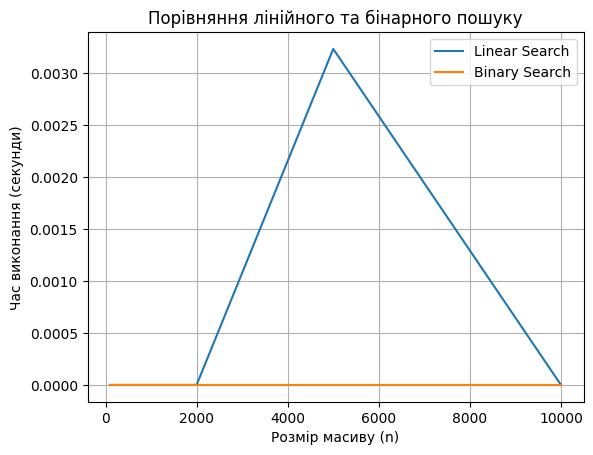

In [ ]:
import matplotlib.pyplot as plt
def plot_results(df_linear, df_binary):
    plt.figure()
    plt.plot(df_linear["n"], df_linear["time"], label="Linear Search")
    plt.plot(df_binary["n"], df_binary["time"], label="Binary Search")
    plt.xlabel("Розмір масиву (n)")
    plt.ylabel("Час виконання (секунди)")
    plt.title("Порівняння лінійного та бінарного пошуку")
    plt.legend()
    plt.grid(True)
    plt.show()
sizes = [100, 500, 1000, 2000, 5000, 10000]
df_linear = linear_dataframe(sizes)
df_binary = binary_dataframe(sizes)
plot_results(df_linear, df_binary)   

**оцінити, який з двох алгоритмів є ефективнішим і в якому діапазоні розміру задачі.**

Лінійний пошук послідовно перевіряє кожен елемент масиву, тому має часову складність O(n).
Бінарний пошук працює лише з відсортованими масивами і щоразу ділить область пошуку навпіл, що забезпечує складність O(logn). 
За результатами аналізу та експериментів встановлено, що бінарний пошук є значно ефективнішим при середніх та великих розмірах масиву. 
Лінійний пошук доцільно використовувати лише для малих або невідсортованих наборів даних. Таким чином, найбільш продуктивним алгоритмом для великих обсягів даних є бінарний пошук.

### **Контрольні питання**

**1. Сформулювати задачу пошуку.**

Задача пошуку полягає у знаходженні потрібного елемента (ключа) в наборі даних (масиві, списку, структурі даних) або визначенні його відсутності. Результатом є індекс елемента або повідомлення про те, що елемент не знайдено.

**2. Які критерії можна використовувати для оцінювання ефективності алгоритмів пошуку?**

* часовa складність виконання алгоритму;
* просторова складність (використання пам’яті);
* кількість операцій порівняння;
* ефективність при зростанні розміру вхідних даних;

**3. Що таке лінійний пошук і яка його асимптотична складність?**


Лінійний пошук - це алгоритм, який послідовно перевіряє кожен елемент масиву до знаходження потрібного значення або завершення списку.

**4. Що таке бінарний (двійковий) пошук і в чому полягає його головний принцип роботи?** 

Бінарний пошук 4 це алгоритм пошуку в відсортованому масиві, який кожного разу ділить масив навпіл і вибирає ту частину, де може знаходитись елемент.
Головний принцип: порівняння з середнім елементом і відкидання половини даних на кожному кроці.

**5. Які переваги і недоліки використання бінарного пошуку порівняно з лінійним?**

дуже швидкий на великих масивах, але працює тільки з відсортованими даними та складніший у реалізації, ніж лінійний пошук.